In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("Unemployment in India.csv")
dataset.head(3)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural


In [3]:
dataset.columns = dataset.columns.str.strip()

In [4]:
print("\nMissing Values:\n", dataset.isnull().sum())


Missing Values:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [5]:
dataset = dataset.dropna()

In [6]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 46.2+ KB
None


In [7]:
print(dataset.describe())

       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                                  72.570000  


In [9]:
avg_unemployment = dataset['Estimated Unemployment Rate (%)'].mean()
print("\nAverage Unemployment Rate:", avg_unemployment)


Average Unemployment Rate: 11.787945945945946


In [10]:

state_unemployment = dataset.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print("\nState-wise Average Unemployment Rate:")
print(state_unemployment)


State-wise Average Unemployment Rate:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


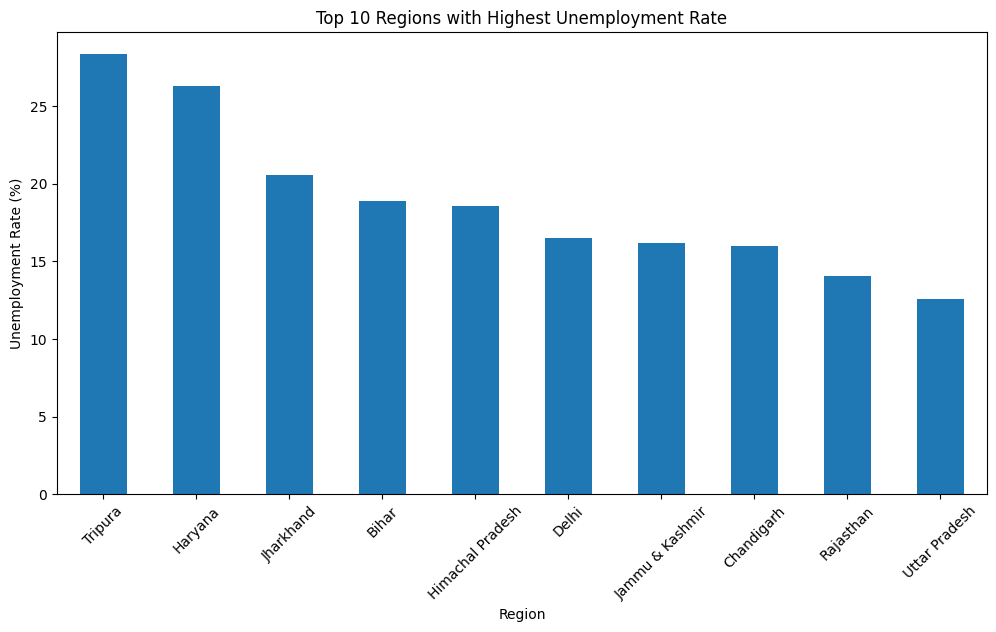

In [11]:
plt.figure(figsize=(12,6))
state_unemployment.head(10).plot(kind='bar')
plt.title("Top 10 Regions with Highest Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

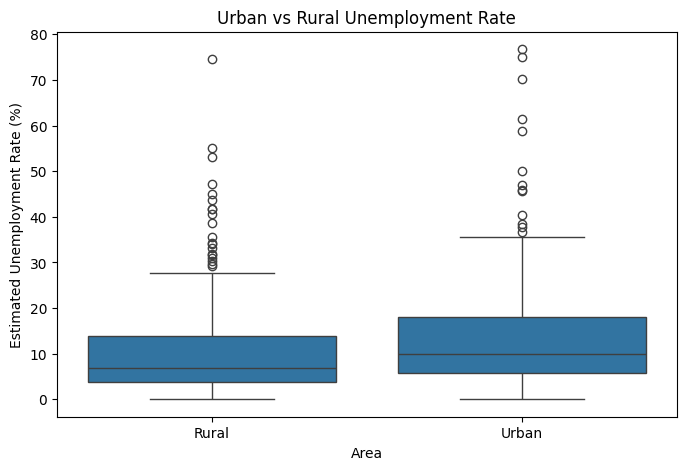

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=dataset)
plt.title("Urban vs Rural Unemployment Rate")
plt.show()

In [ ]:
# Monthly unemployment trend
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

monthly_trend = df.groupby(df['Date'].dt.month)['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
monthly_trend.plot(marker='o')
plt.title("Monthly Average Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Key Insights
print("\n----- Key Insights -----")
print("1. Some regions have significantly higher unemployment rates.")
print("2. Urban and rural unemployment patterns are different.")
print("3. Certain months show higher unemployment trends.")
print("4. These insights can help the government create employment policies and skill development programs.")